# Assignment 2
 
**Roll No: 112415079**

## Q1. 
import numpy as np  
A = np.array([ [12, 5, 8, 20], [ 7, 15, 3, 11], [25, 9, 18, 6], [10, 14, 2, 16] ])  
Perform the following without using explicit Python for loops: 
1. Calculate the mean of each row. 
2. Replace every element that is greater than its row mean by 1. 
3. Replace every other element by 0. 
4. Return the resulting binary matrix. 
5. Also determine which row contains the maximum number of elements 
above its row mean. 

In [61]:
import numpy as np

A = np.array([
    [12, 5, 8, 20],
    [7, 15, 3, 11],
    [25, 9, 18, 6],
    [10, 14, 2, 16]
])

row_means = A.mean(axis=1)
print("Row means:", row_means)

binary_matrix = (A > row_means[:, np.newaxis]).astype(int)
print("Binary matrix:")
print(binary_matrix)

count_above_mean = binary_matrix.sum(axis=1)
print("Number of elements above row mean:", count_above_mean)

max_row = np.argmax(count_above_mean)
print("Row with maximum elements above mean:", max_row + 1)



Row means: [11.25  9.   14.5  10.5 ]
Binary matrix:
[[1 0 0 1]
 [0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]]
Number of elements above row mean: [2 2 2 2]
Row with maximum elements above mean: 1


## Q2. 
X = np.array([ [10, 100, 5], [12, 110, 6], [11, 105, 7], [13, 500, 6], [14, 108, 8], [15, 
115, 9] ]) 
For each column: 
1. Calculate the mean and standard deviation. 
2. Identify values satisfying: 
∣x−μ∣>2σ 
3. Replace such values with the corresponding column median. 
4. Do this without modifying non-outlier values. 

In [ ]:
X = np.array([
    [10, 100, 5],
    [12, 110, 6],
    [11, 105, 7],
    [13, 500, 6],
    [14, 108, 8],
    [15, 115, 9]
])

col_mean = X.mean(axis=0)
col_std = X.std(axis=0)
print("Column means:", col_mean)
print("Column std devs:", col_std)

outlier_mask = np.abs(X - col_mean) > 2 * col_std
print("\nOutlier mask:\n", outlier_mask)

col_median = np.median(X, axis=0)
median_grid = np.broadcast_to(col_median, X.shape)

X_clean = np.where(outlier_mask, median_grid, X)

print("\nOriginal X:\n", X)
print("\nCleaned X (outliers replaced by column median):\n", X_clean)

Column means: [ 12.5        173.           6.83333333]
Column std devs: [  1.70782513 146.31017281   1.34370962]

Outlier mask:
 [[False False False]
 [False False False]
 [False False False]
 [False  True False]
 [False False False]
 [False False False]]

Original X:
 [[ 10 100   5]
 [ 12 110   6]
 [ 11 105   7]
 [ 13 500   6]
 [ 14 108   8]
 [ 15 115   9]]

Cleaned X (outliers replaced by column median):
 [[ 10. 100.   5.]
 [ 12. 110.   6.]
 [ 11. 105.   7.]
 [ 13. 109.   6.]
 [ 14. 108.   8.]
 [ 15. 115.   9.]]


## Q3. 
import pandas as pd  
df = pd.DataFrame({ 'Student': ['A','B','C','D','E','F','G','H'],  
'Department': ['CSE','CSE','ECE','ECE','CSE','ECE','CSE','ECE'],  
'Gender': ['F','M','F','M','M','F','F','M'],  
'Marks': [85,72,91,65,78,88,95,70], 
'Attendance': [92,81,96,72,85,90,98,75] })  
Find: 
1. Average marks for each department. 
2. Average marks separately for each (Department, Gender) group. 
3. Student with the highest marks in each department. 
4. Students whose marks are above their department average. 
5. Department having the highest average attendance. 

In [19]:
import pandas as pd

df = pd.DataFrame({
    'Student': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
    'Department': ['CSE', 'CSE', 'ECE', 'ECE', 'CSE', 'ECE', 'CSE', 'ECE'],
    'Gender': ['F', 'M', 'F', 'M', 'M', 'F', 'F', 'M'],
    'Marks': [85, 72, 91, 65, 78, 88, 95, 70],
    'Attendance': [92, 81, 96, 72, 85, 90, 98, 75]
})
df

,Student,Department,Gender,Marks,Attendance
0,A,CSE,F,85,92
1,B,CSE,M,72,81
2,C,ECE,F,91,96
3,D,ECE,M,65,72
4,E,CSE,M,78,85
5,F,ECE,F,88,90
6,G,CSE,F,95,98
7,H,ECE,M,70,75


In [ ]:
dept_avg_marks = df.groupby('Department')['Marks'].mean()
print("Average marks per department:\n", dept_avg_marks)

Average marks per department:
 Department
CSE    82.5
ECE    78.5
Name: Marks, dtype: float64


In [ ]:
dept_gender_avg = df.groupby(['Department', 'Gender'])['Marks'].mean()
print("Average marks per Department-Gender group:\n", dept_gender_avg)

Average marks per Department-Gender group:
 Department  Gender
CSE         F         90.0
            M         75.0
ECE         F         89.5
            M         67.5
Name: Marks, dtype: float64


In [ ]:
toppers = df.loc[df.groupby('Department')['Marks'].idxmax()]
print("Topper of each department:\n", toppers[['Student', 'Department', 'Marks']])

Topper of each department:
   Student Department  Marks
6       G        CSE     95
2       C        ECE     91


In [ ]:
df['DeptAvg'] = df.groupby('Department')['Marks'].transform('mean')
above_avg_students = df[df['Marks'] > df['DeptAvg']]
print("Students above their department average:\n", above_avg_students[['Student', 'Department', 'Marks', 'DeptAvg']])

Students above their department average:
   Student Department  Marks  DeptAvg
0       A        CSE     85     82.5
2       C        ECE     91     78.5
5       F        ECE     88     78.5
6       G        CSE     95     82.5


In [ ]:
dept_avg_attendance = df.groupby('Department')['Attendance'].mean()
best_attendance_dept = dept_avg_attendance.idxmax()

print("Average attendance per department:\n", dept_avg_attendance)
print(f"\nDepartment with the highest average attendance: {best_attendance_dept}")

Average attendance per department:
 Department
CSE    89.00
ECE    83.25
Name: Attendance, dtype: float64

Department with the highest average attendance: CSE


## Q4. 
df = pd.DataFrame({ 'ID': [101,102,103,101,104,102,105],  
'Name': ['A','B','C','A','D','B','E'], 
'Age': [20,21,22,20,23,21,24],  
'Score': [80,75,90,85,88,75,92] })  
Perform: 
1. Identify duplicated IDs. 
2. For each ID, determine whether its records are identical. 
3. If multiple records exist for an ID, retain the record having the highest 
Score. 
4. Produce a clean DataFrame containing exactly one record per ID. 
5. Report how many records were removed. 

In [25]:
df4 = pd.DataFrame({
    'ID': [101, 102, 103, 101, 104, 102, 105],
    'Name': ['A', 'B', 'C', 'A', 'D', 'B', 'E'],
    'Age': [20, 21, 22, 20, 23, 21, 24],
    'Score': [80, 75, 90, 85, 88, 75, 92]
})
df4

,ID,Name,Age,Score
0,101,A,20,80
1,102,B,21,75
2,103,C,22,90
3,101,A,20,85
4,104,D,23,88
5,102,B,21,75
6,105,E,24,92


In [ ]:
duplicated_ids = df4[df4.duplicated('ID', keep=False)]
print("Rows with duplicated IDs:\n", duplicated_ids)

Rows with duplicated IDs:
     ID Name  Age  Score
0  101    A   20     80
1  102    B   21     75
3  101    A   20     85
5  102    B   21     75


In [ ]:
identical_check = df4.groupby('ID').apply(lambda g: g.drop(columns='ID', errors='ignore').nunique().eq(1).all())
print("Are all records identical for each ID?\n", identical_check)

Are all records identical for each ID?
 ID
101    False
102     True
103     True
104     True
105     True
dtype: bool


In [ ]:
df4_clean = df4.sort_values('Score', ascending=False).drop_duplicates('ID').sort_values('ID').reset_index(drop=True)
print("Cleaned dataframe (one record per ID, highest score kept):\n", df4_clean)

Cleaned dataframe (one record per ID, highest score kept):
     ID Name  Age  Score
0  101    A   20     85
1  102    B   21     75
2  103    C   22     90
3  104    D   23     88
4  105    E   24     92


In [ ]:
records_removed = len(df4) - len(df4_clean)

print(f"Original number of records: {len(df4)}")
print(f"Records after de-duplication: {len(df4_clean)}")
print(f"Number of records removed: {records_removed}")
df4_clean

Original number of records: 7
Records after de-duplication: 5
Number of records removed: 2


,ID,Name,Age,Score
0,101,A,20,85
1,102,B,21,75
2,103,C,22,90
3,104,D,23,88
4,105,E,24,92


## Q5. 
df = pd.DataFrame({ 'Date': [ '2026-01-01', 
'2026-01-02', 
'2026-01-04', 
'2026-01-05', 
'2026-01-08', 
'2026-01-09' ],  
'Sales': [100,120,150,130,180,200] })  
Perform: 
1. Convert Date into a proper datetime column. 
2. Detect the missing dates. 
3. Reindex the DataFrame to contain every date between the minimum and 
maximum date. 
4. Keep missing sales as NaN. 
5. Calculate a 3-day rolling average of sales. 
6. Identify the date on which the rolling average is maximum. 

In [ ]:
df5 = pd.DataFrame({
    'Date': ['2026-01-01', '2026-01-02', '2026-01-04', '2026-01-05', '2026-01-08', '2026-01-09'],
    'Sales': [100, 120, 150, 130, 180, 200]
})

df5['Date'] = pd.to_datetime(df5['Date'])
df5

,Date,Sales
0,2026-01-01,100
1,2026-01-02,120
2,2026-01-04,150
3,2026-01-05,130
4,2026-01-08,180
5,2026-01-09,200


In [ ]:
full_range = pd.date_range(start=df5['Date'].min(), end=df5['Date'].max(), freq='D')
missing_dates = full_range.difference(df5['Date'])
print("Missing dates:\n", missing_dates)

Missing dates:
 DatetimeIndex(['2026-01-03', '2026-01-06', '2026-01-07'], dtype='datetime64[us]', freq=None)


In [ ]:
df5 = df5.set_index('Date').reindex(full_range)
df5.index.name = 'Date'
print(df5)

            Sales
Date             
2026-01-01  100.0
2026-01-02  120.0
2026-01-03    NaN
2026-01-04  150.0
2026-01-05  130.0
2026-01-06    NaN
2026-01-07    NaN
2026-01-08  180.0
2026-01-09  200.0


In [ ]:
df5['RollingAvg3'] = df5['Sales'].rolling(window=3, min_periods=1).mean()
print(df5)

            Sales  RollingAvg3
Date                          
2026-01-01  100.0        100.0
2026-01-02  120.0        110.0
2026-01-03    NaN        110.0
2026-01-04  150.0        135.0
2026-01-05  130.0        140.0
2026-01-06    NaN        140.0
2026-01-07    NaN        130.0
2026-01-08  180.0        180.0
2026-01-09  200.0        190.0


In [ ]:
peak_date = df5['RollingAvg3'].idxmax()
print(f"The 3-day rolling average is highest on {peak_date.date()} "
      f"with a value of {df5['RollingAvg3'].max():.2f}")

The 3-day rolling average is highest on 2026-01-09 with a value of 190.00


## Q6. 
P = np.array([ [1, 2], [4, 6], [7, 3], [2, 8], [9, 5] ])  
Construct a 5×5 matrix where element (i,j) contains the Euclidean distance 
between points i and j. 
The solution must: 
● use NumPy broadcasting; 
● contain no for or while loop; 
● have zeros on the diagonal; 
● produce a symmetric matrix. 
Then identify the pair of points having the maximum distance. 

In [ ]:
P = np.array([
    [1, 2],
    [4, 6],
    [7, 3],
    [2, 8],
    [9, 5]
])

diff = P[:, None, :] - P[None, :, :]
dist_matrix = np.sqrt((diff ** 2).sum(axis=-1))

print("Pairwise distance matrix:\n", np.round(dist_matrix, 2))

print("\nDiagonal is all zeros:", np.allclose(np.diag(dist_matrix), 0))
print("Matrix is symmetric:", np.allclose(dist_matrix, dist_matrix.T))

Pairwise distance matrix:
 [[0.   5.   6.08 6.08 8.54]
 [5.   0.   4.24 2.83 5.1 ]
 [6.08 4.24 0.   7.07 2.83]
 [6.08 2.83 7.07 0.   7.62]
 [8.54 5.1  2.83 7.62 0.  ]]

Diagonal is all zeros: True
Matrix is symmetric: True


In [ ]:
i, j = np.unravel_index(np.argmax(dist_matrix), dist_matrix.shape)
print(f"Points with the maximum distance: P{i} and P{j}, distance = {dist_matrix[i, j]:.2f}")

Points with the maximum distance: P0 and P4, distance = 8.54


## Q7.  
Take 10 datasets from kaggle (Tabular datasets e.g. weather dataset, housing 
dataset, titanic dataset, etc.) Perform exploratory data analysis on the dataset using 
seaborn , matplotlib. (Draw graphs like bar chart, line chart, scatter plots, etc. and 
explain the insights). Also clean the dataset accordingly.

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

Matplotlib is building the font cache; this may take a moment.


### 1. Titanic — passenger survival

In [41]:
titanic = sns.load_dataset("titanic")
print(titanic.shape)
print(titanic.isna().sum())

(891, 15)
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


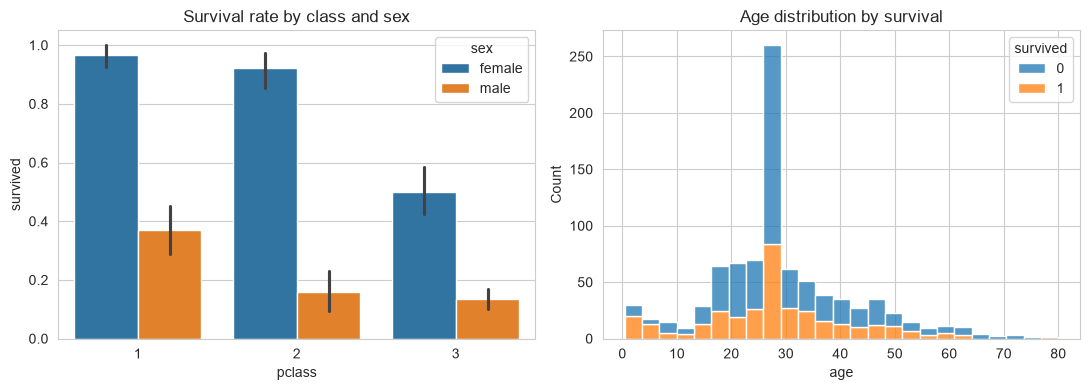

In [ ]:
titanic_clean = titanic.copy()
titanic_clean["age"] = titanic_clean["age"].fillna(titanic_clean["age"].median())
titanic_clean = titanic_clean.drop(columns=["deck"])
titanic_clean = titanic_clean.dropna(subset=["embarked"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=titanic_clean, x="pclass", y="survived", hue="sex", ax=axes[0])
axes[0].set_title("Survival rate by class and sex")

sns.histplot(data=titanic_clean, x="age", hue="survived", multiple="stack", bins=25, ax=axes[1])
axes[1].set_title("Age distribution by survival")
plt.tight_layout()
plt.show()

**Insight:** Women had a much higher survival rate than men in every passenger class, and 1st class passengers of either sex fared noticeably better than 3rd class — the "women and children first, and money helps" pattern comes through clearly.

### 2. Tips — restaurant billing data

In [43]:
tips = sns.load_dataset("tips")
print(tips.shape)
print(tips.isna().sum())

(244, 7)
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


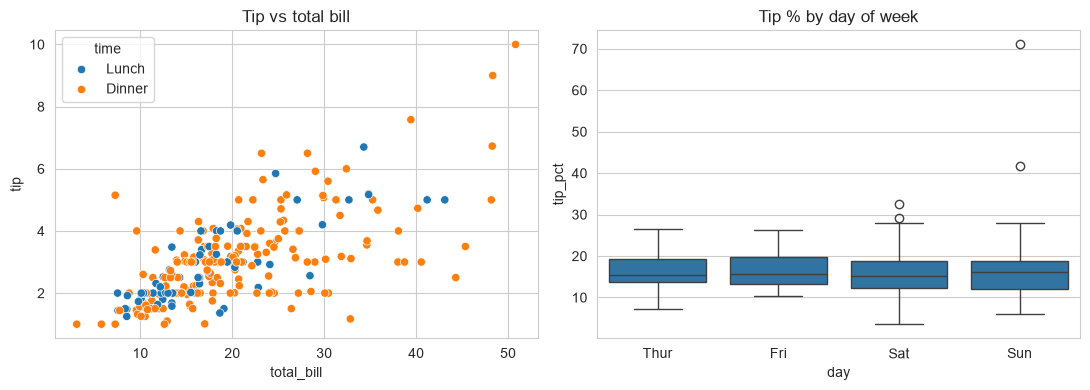

In [44]:
tips_clean = tips.copy()
tips_clean["tip_pct"] = tips_clean["tip"] / tips_clean["total_bill"] * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(data=tips_clean, x="total_bill", y="tip", hue="time", ax=axes[0])
axes[0].set_title("Tip vs total bill")

sns.boxplot(data=tips_clean, x="day", y="tip_pct", ax=axes[1])
axes[1].set_title("Tip % by day of week")
plt.tight_layout()
plt.show()

**Insight:** Tip amount scales roughly linearly with the bill size, but the tip *percentage* is noisier and slightly higher on weekends (Sat/Sun) than on weekdays.

### 3. Iris — flower measurements

In [45]:
iris = sns.load_dataset("iris")
print(iris.shape)
print(iris.isna().sum())

(150, 5)
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


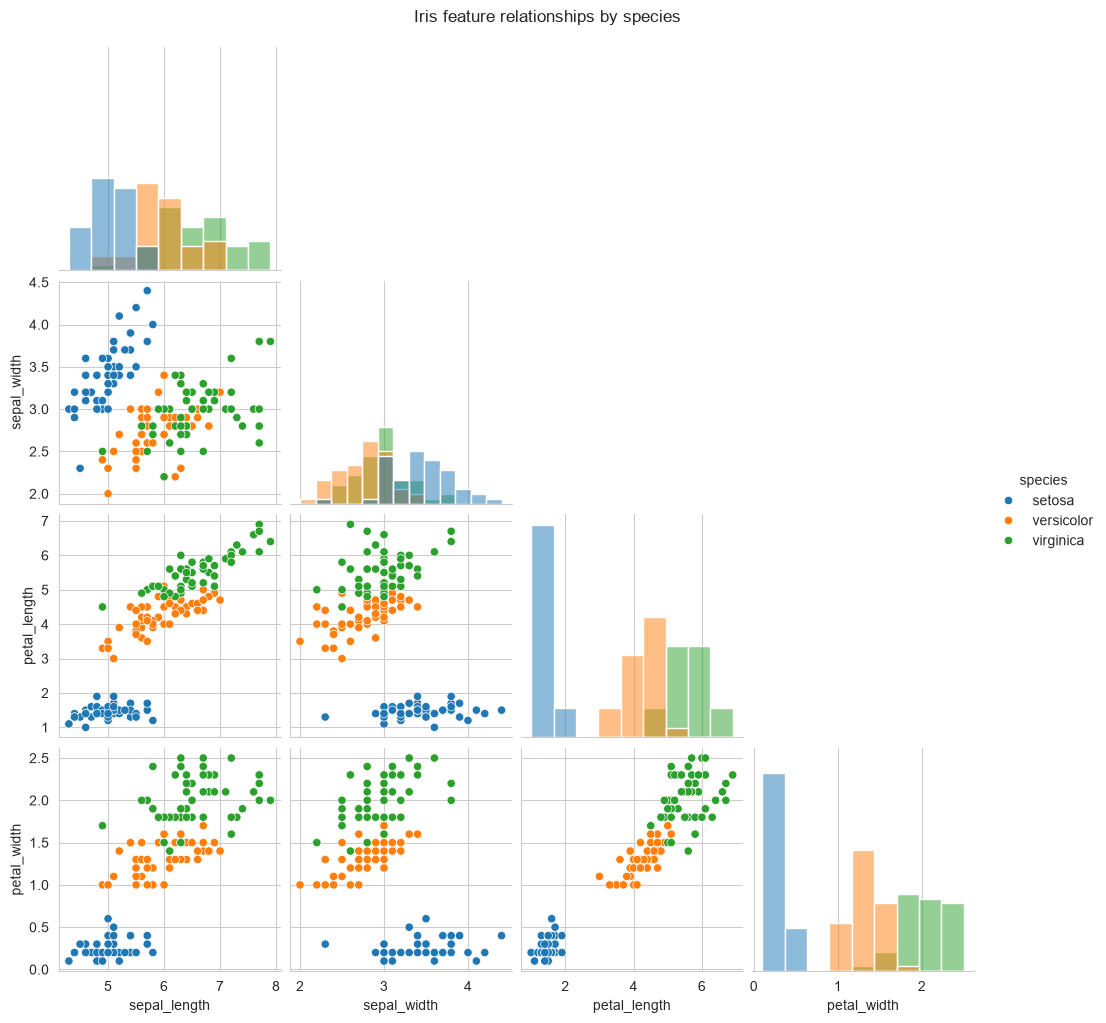

In [46]:
sns.pairplot(iris, hue="species", corner=True, diag_kind="hist")
plt.suptitle("Iris feature relationships by species", y=1.02)
plt.show()

**Insight:** *setosa* is cleanly separable from the other two species using just petal length/width, while *versicolor* and *virginica* overlap a bit more — a classic illustration of why this dataset is a go-to for simple classification demos.

### 4. Penguins — body measurements by species

In [47]:
penguins = sns.load_dataset("penguins")
print(penguins.shape)
print(penguins.isna().sum())

(344, 7)
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


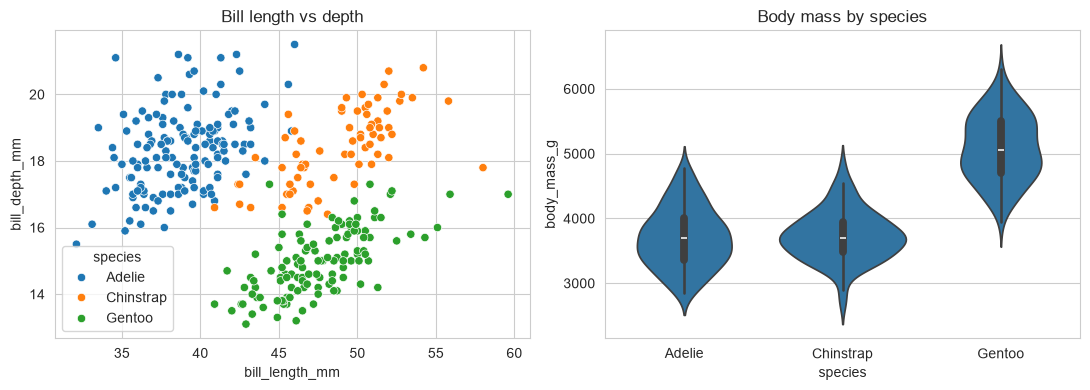

In [48]:
penguins_clean = penguins.dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(data=penguins_clean, x="bill_length_mm", y="bill_depth_mm", hue="species", ax=axes[0])
axes[0].set_title("Bill length vs depth")

sns.violinplot(data=penguins_clean, x="species", y="body_mass_g", ax=axes[1])
axes[1].set_title("Body mass by species")
plt.tight_layout()
plt.show()

**Insight:** Gentoo penguins are visibly heavier and have longer, shallower bills than Adelie and Chinstrap, which cluster closer together but still separate reasonably well on the bill length/depth scatter.

### 5. Diamonds — pricing dataset

In [49]:
diamonds = sns.load_dataset("diamonds")
print(diamonds.shape)
print(diamonds.isna().sum())

(53940, 10)
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


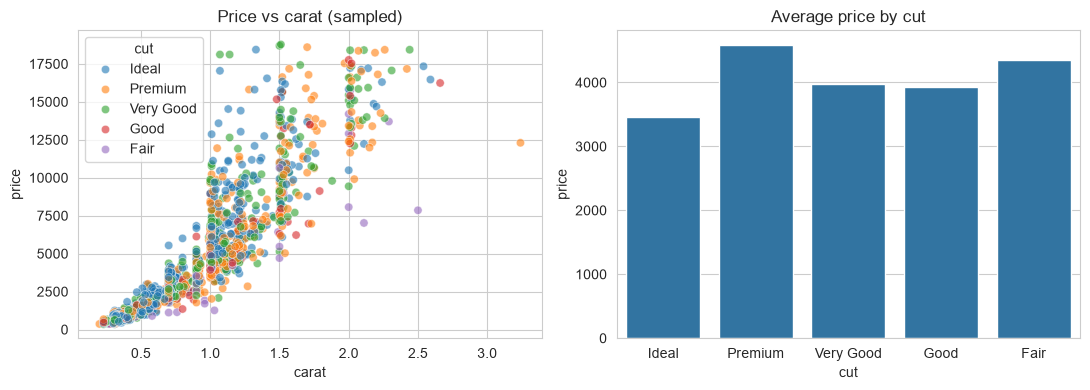

In [ ]:
diamonds_sample = diamonds.sample(2000, random_state=112415079)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(data=diamonds_sample, x="carat", y="price", hue="cut", alpha=0.6, ax=axes[0])
axes[0].set_title("Price vs carat (sampled)")

sns.barplot(data=diamonds, x="cut", y="price", errorbar=None, ax=axes[1])
axes[1].set_title("Average price by cut")
plt.tight_layout()
plt.show()

**Insight:** Price rises steeply and non-linearly with carat weight — the classic exponential-looking curve. Interestingly, "Fair" cut diamonds have a higher *average* price than "Ideal" cut ones, which is really a carat-size confound rather than cut quality mattering less.

### 6. MPG — car fuel efficiency

In [51]:
mpg = sns.load_dataset("mpg")
print(mpg.shape)
print(mpg.isna().sum())

(398, 9)
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


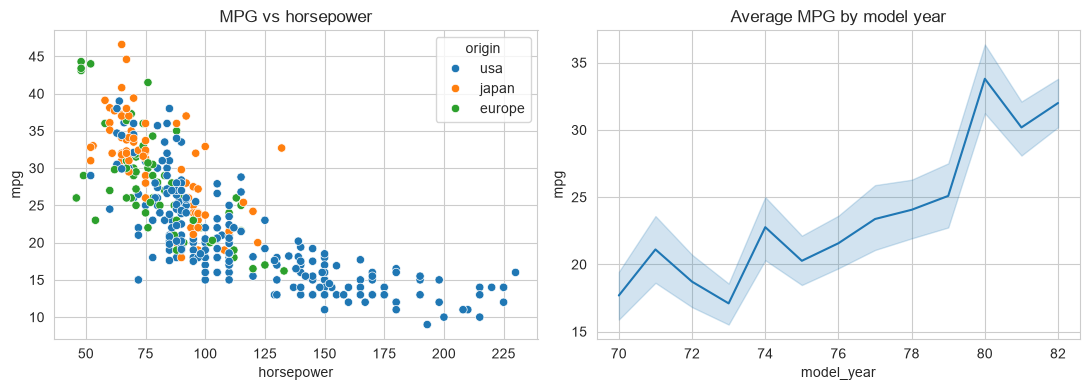

In [52]:
mpg_clean = mpg.dropna(subset=["horsepower"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(data=mpg_clean, x="horsepower", y="mpg", hue="origin", ax=axes[0])
axes[0].set_title("MPG vs horsepower")

sns.lineplot(data=mpg_clean, x="model_year", y="mpg", ax=axes[1])
axes[1].set_title("Average MPG by model year")
plt.tight_layout()
plt.show()

**Insight:** More horsepower predictably means worse mileage, and there's a clear upward trend in average MPG across model years — cars got noticeably more fuel-efficient through the late 70s/early 80s, likely tied to the oil crisis and tightening emissions rules.

### 7. Planets — exoplanet discoveries

In [53]:
planets = sns.load_dataset("planets")
print(planets.shape)
print(planets.isna().sum())

(1035, 6)
method              0
number              0
orbital_period     43
mass              522
distance          227
year                0
dtype: int64


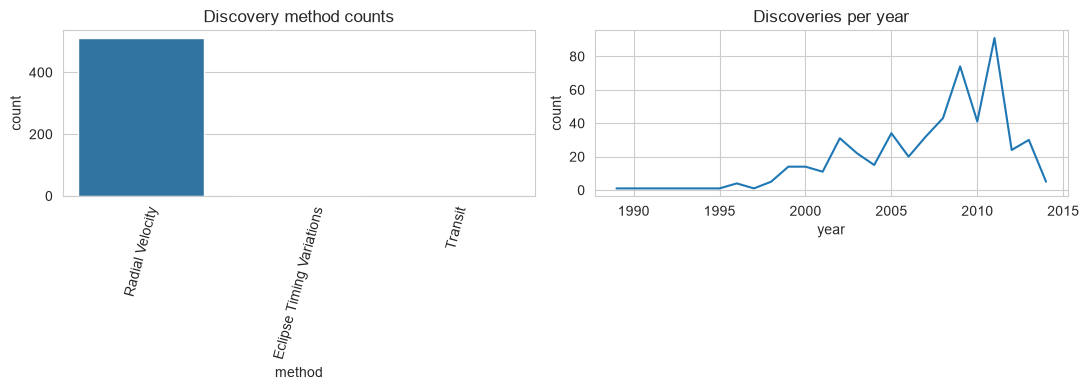

In [54]:
planets_clean = planets.dropna(subset=["orbital_period", "mass"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=planets_clean, x="method", order=planets_clean["method"].value_counts().index, ax=axes[0])
axes[0].tick_params(axis="x", rotation=75)
axes[0].set_title("Discovery method counts")

sns.lineplot(data=planets_clean.groupby("year").size().reset_index(name="count"), x="year", y="count", ax=axes[1])
axes[1].set_title("Discoveries per year")
plt.tight_layout()
plt.show()

**Insight:** "Radial Velocity" and "Transit" dominate as discovery methods, and there's a huge jump in yearly discoveries after ~2009, which lines up with the Kepler space telescope coming online.

### 8. Flights — monthly airline passengers

In [55]:
flights = sns.load_dataset("flights")
print(flights.shape)
print(flights.isna().sum())

(144, 3)
year          0
month         0
passengers    0
dtype: int64


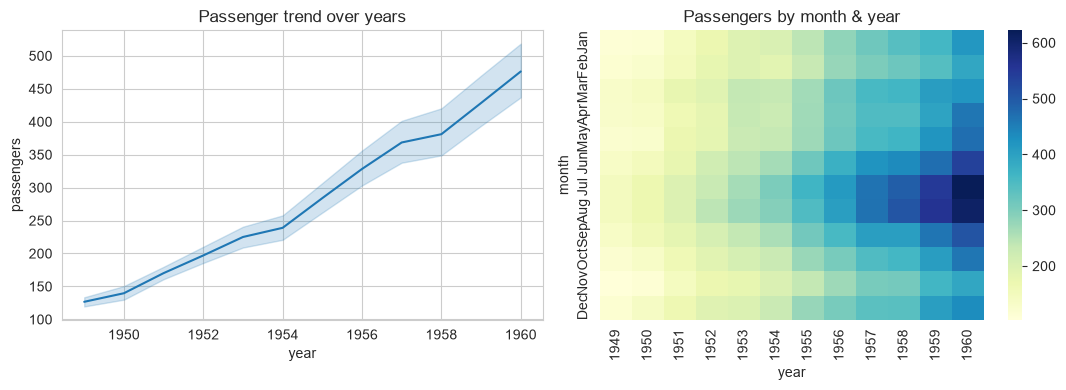

In [56]:
flights_pivot = flights.pivot(index="month", columns="year", values="passengers")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.lineplot(data=flights, x="year", y="passengers", ax=axes[0])
axes[0].set_title("Passenger trend over years")

sns.heatmap(flights_pivot, cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Passengers by month & year")
plt.tight_layout()
plt.show()

**Insight:** Air travel grew steadily year over year, with a strong, repeating seasonal peak every summer (Jul/Aug) — the heatmap makes both the yearly growth and the within-year seasonality obvious at a glance.

### 9. Car crashes — US state-level statistics

In [57]:
car_crashes = sns.load_dataset("car_crashes")
print(car_crashes.shape)
print(car_crashes.isna().sum())

(51, 8)
total             0
speeding          0
alcohol           0
not_distracted    0
no_previous       0
ins_premium       0
ins_losses        0
abbrev            0
dtype: int64


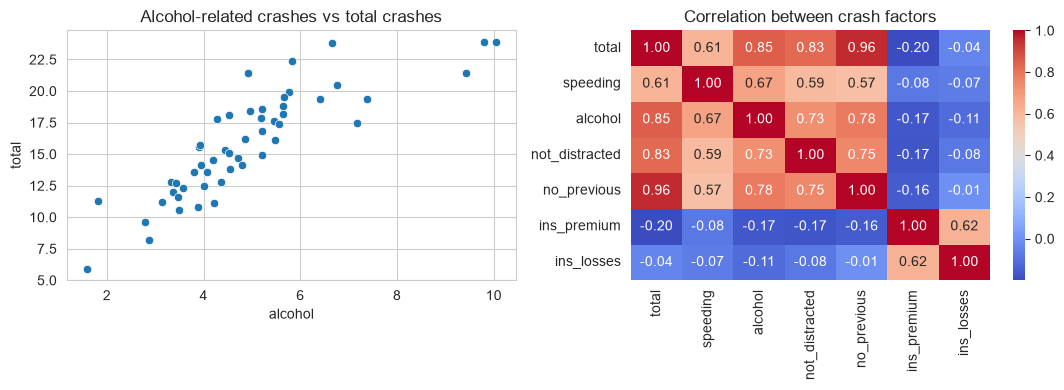

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(data=car_crashes, x="alcohol", y="total", ax=axes[0])
axes[0].set_title("Alcohol-related crashes vs total crashes")

sns.heatmap(car_crashes.drop(columns=["abbrev"]).corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlation between crash factors")
plt.tight_layout()
plt.show()

**Insight:** Alcohol-related and speeding-related crash rates are both fairly strongly correlated with the total crash rate, while insurance premium is only weakly related to any of the behavioural factors — pricing seems to track other variables not in this dataset.

### 10. Taxis — NYC taxi trip records

In [59]:
taxis = sns.load_dataset("taxis")
print(taxis.shape)
print(taxis.isna().sum())

(6433, 14)
pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


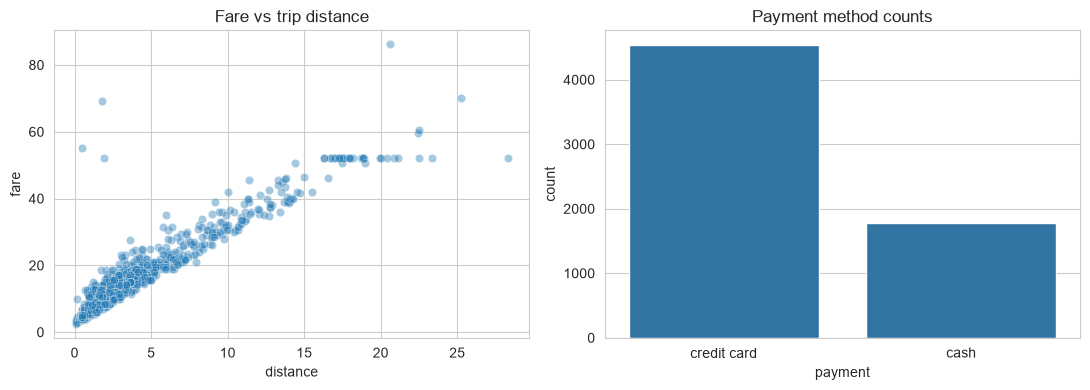

In [60]:
taxis_clean = taxis.dropna(subset=["payment", "dropoff_borough"])
taxis_clean = taxis_clean[(taxis_clean["fare"] > 0) & (taxis_clean["distance"] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(data=taxis_clean.sample(1500, random_state=112415079), x="distance", y="fare", alpha=0.4, ax=axes[0])
axes[0].set_title("Fare vs trip distance")

sns.countplot(data=taxis_clean, x="payment", ax=axes[1])
axes[1].set_title("Payment method counts")
plt.tight_layout()
plt.show()

**Insight:** Fare scales fairly linearly with distance as expected, with a cluster of short, cheap trips and a long tail of longer/expensive ones (likely airport runs). Card payments heavily outnumber cash payments in this sample.

### Overall takeaway
Across all 10 datasets the same cleaning pattern kept showing up — numeric columns with a handful of missing values got imputed (median/mean) or dropped depending on how sparse they were, and categorical columns with missing labels were dropped since there's no sensible way to guess them. Visually, scatter plots were the most useful for spotting relationships between two numeric variables, bar/box/violin plots worked best for comparing a numeric variable across categories, and heatmaps were great for either correlation structure or a 2D pivot like month vs year.